In [2]:

class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None
        
def insert(root, key):
    if root is None:
        return Node(key)

    if key < root.key:
        root.left = insert(root.left, key)
    elif key > root.key:
        root.right = insert(root.right, key)
    return root

def inorder(root):
    if root is not None:
        inorder(root.left)
        print(root.key, end=" ")
        inorder(root.right)

def preorder(root):
    if root is not None:
        print(root.key, end=" ")
        preorder(root.left)
        preorder(root.right)

def postorder(root):
    if root is not None:
        postorder(root.left)
        postorder(root.right)
        print(root.key, end=" ")

def search(root, key):
    if root is None:
        return False

    if root.key == key:
        return True

    if key < root.key:
        return search(root.left, key)
    else:
        return search(root.right, key)

keys = [50, 30, 70, 20, 40, 60, 80, 10]

root = None
for key in keys:
    root = insert(root, key)

print("Inorder traversal:")
inorder(root)

print("\nPreorder traversal:")
preorder(root)

print("\nPostorder traversal:")
postorder(root)

inorder_list = []

def store_inorder(root):
    if root is not None:
        store_inorder(root.left)
        inorder_list.append(root.key)
        store_inorder(root.right)

store_inorder(root)

if inorder_list == sorted(inorder_list):
    print("\n\nInorder traversal is in sorted order.")
else:
    print("\n\nInorder traversal is not in sorted order.")


key1 = 60
if search(root, key1):
    print(key1, "found in the BST.")
else:
    print(key1, "not found in the BST.")


key2 = 100
if search(root, key2):
    print(key2, "found in the BST.")
else:
    print(key2, "not found in the BST.")

Inorder traversal:
10 20 30 40 50 60 70 80 
Preorder traversal:
50 30 20 10 40 70 60 80 
Postorder traversal:
10 20 40 30 60 80 70 50 

Inorder traversal is in sorted order.
60 found in the BST.
100 not found in the BST.


In [3]:

class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None

def insert(root, key):
    if root is None:
        return Node(key)

    if key < root.key:
        root.left = insert(root.left, key)
    elif key > root.key:
        root.right = insert(root.right, key)

    return root

def inorder(root):
    if root is not None:
        inorder(root.left)
        print(root.key, end=" ")
        inorder(root.right)

def find_min(root):
    current = root

    while current.left is not None:
        current = current.left

    return current

def delete(root, key):

    if root is None:
        return None
        
    if key < root.key:
        root.left = delete(root.left, key)


    elif key > root.key:
        root.right = delete(root.right, key)

    else:

        if root.left is None and root.right is None:
            return None

        elif root.left is None:
            return root.right
        elif root.right is None:
            return root.left
        else:
            successor = find_min(root.right)
            root.key = successor.key

            root.right = delete(root.right, successor.key)
    return root

keys = [50, 30, 70, 20, 40, 60, 80, 10]
root = None

for key in keys:
    root = insert(root, key)

print("Original BST:")
inorder(root)
print()

print("\nAfter deleting leaf node 40:")
root = delete(root, 40)
inorder(root)
print()

print("\nAfter deleting node 20 (one child):")
root = delete(root, 20)
inorder(root)
print()

print("\nAfter deleting node 50 (two children):")
root = delete(root, 50)
inorder(root)
print()

Original BST:
10 20 30 40 50 60 70 80 

After deleting leaf node 40:
10 20 30 50 60 70 80 

After deleting node 20 (one child):
10 30 50 60 70 80 

After deleting node 50 (two children):
10 30 60 70 80 



BST PERFORMANCE EXPERIMENT

Testing n = 1000
----------------------------------------------------------------------------------------------------
Random          | Build: 0.002147 sec | Height:    25 | Search: 0.001967 sec | Delete: 0.002375 sec
Sorted          | Build: 0.081042 sec | Height:  1000 | Search: 0.078184 sec | Delete: 0.034362 sec
Reverse-sorted  | Build: 0.061910 sec | Height:  1000 | Search: 0.082577 sec | Delete: 0.028586 sec

Testing n = 5000
----------------------------------------------------------------------------------------------------
Random          | Build: 0.016334 sec | Height:    28 | Search: 0.001919 sec | Delete: 0.002322 sec
Sorted          | Build: 2.046639 sec | Height:  5000 | Search: 0.358345 sec | Delete: 0.200721 sec
Reverse-sorted  | Build: 1.385875 sec | Height:  5000 | Search: 0.399227 sec | Delete: 0.199500 sec

Testing n = 10000
----------------------------------------------------------------------------------------------------
Random        

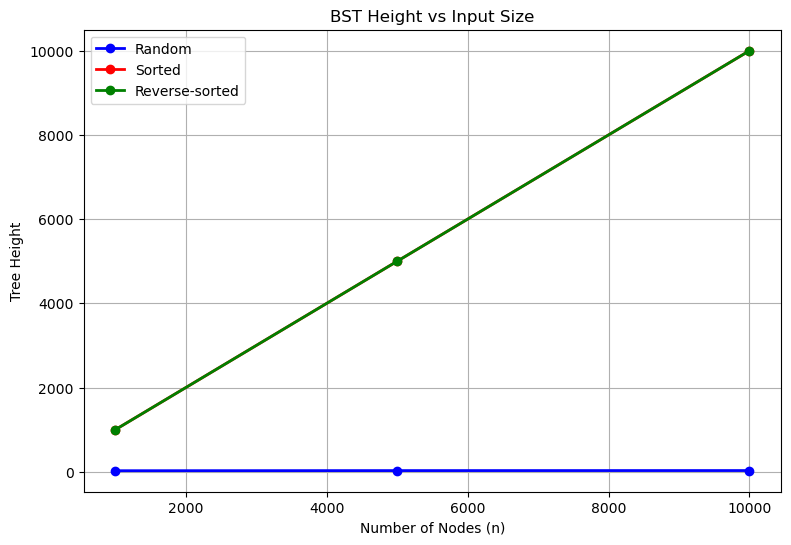

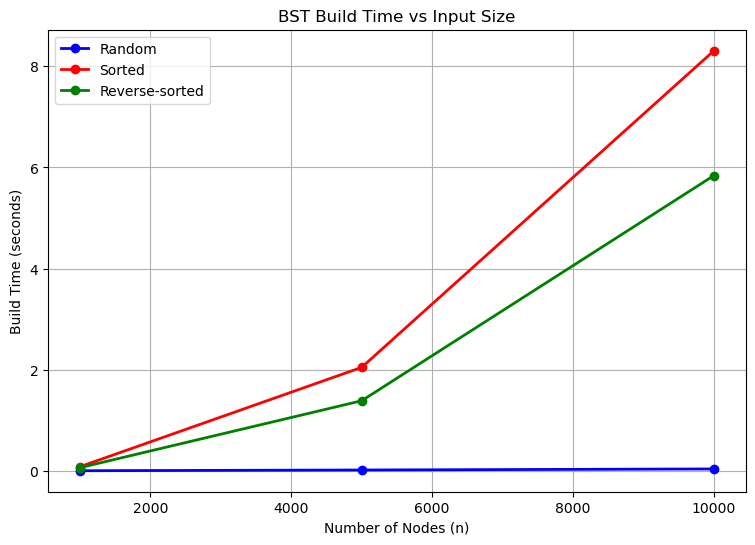

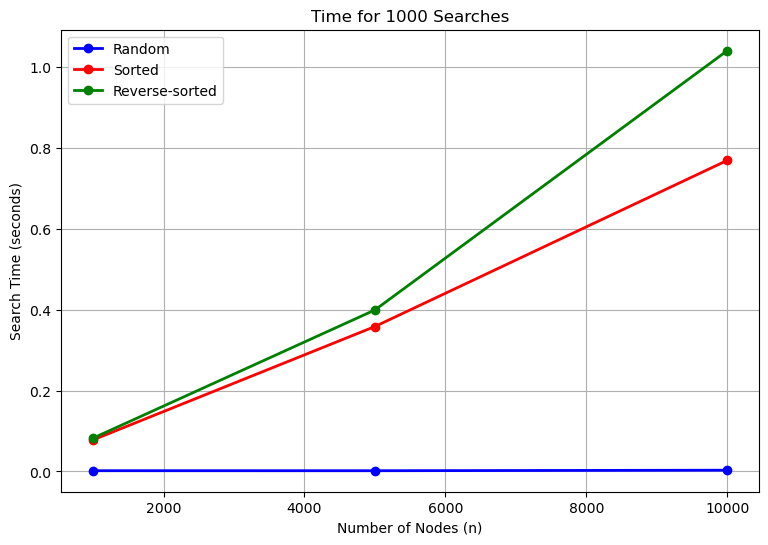

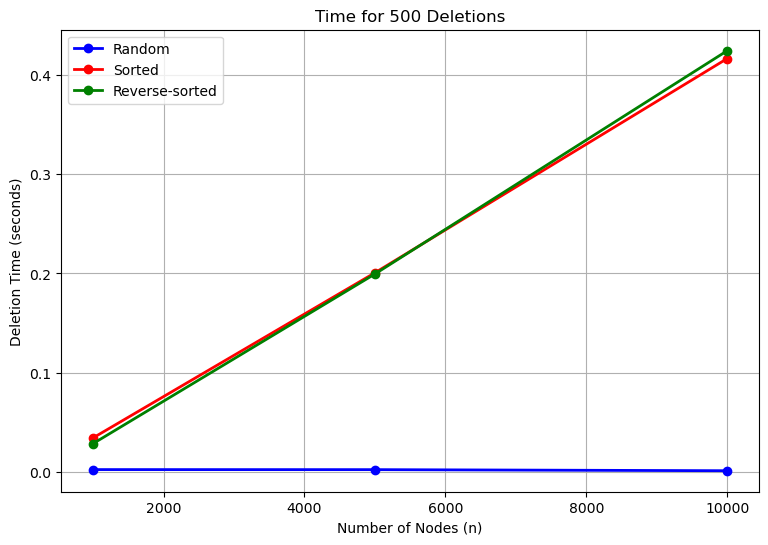

In [5]:
import random
import time
import csv
import matplotlib.pyplot as plt

class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None

class BST:

    def __init__(self):
        self.root = None

    def insert(self, key):

        new_node = Node(key)
        
        if self.root is None:
            self.root = new_node
            return

        current = self.root

        while True:

            if key < current.key:

                if current.left is None:
                    current.left = new_node
                    return

                current = current.left

            elif key > current.key:

                if current.right is None:
                    current.right = new_node
                    return

                current = current.right

            else:
                return

    def search(self, key):

        current = self.root

        while current is not None:

            if key == current.key:
                return True

            elif key < current.key:
                current = current.left

            else:
                current = current.right

        return False
        
    def find_min(self, node):

        current = node

        while current.left is not None:
            current = current.left

        return current

    def delete(self, key):

        parent = None
        current = self.root

        while current is not None and current.key != key:

            parent = current

            if key < current.key:
                current = current.left
            else:
                current = current.right

        if current is None:
            return
        if current.left is None or current.right is None:
            if current.left is not None:
                child = current.left
            else:
                child = current.right
            if parent is None:
                self.root = child

            elif parent.left == current:
                parent.left = child

            else:
                parent.right = child

      
        else:
            successor_parent = current
            successor = current.right

            while successor.left is not None:
                successor_parent = successor
                successor = successor.left
            current.key = successor.key
            if successor_parent.left == successor:
                successor_parent.left = successor.right
            else:
                successor_parent.right = successor.right

    def height(self):

        if self.root is None:
            return 0

        max_height = 0
        stack = [(self.root, 1)]

        while stack:

            node, level = stack.pop()

            max_height = max(max_height, level)

            if node.left is not None:
                stack.append((node.left, level + 1))

            if node.right is not None:
                stack.append((node.right, level + 1))

        return max_height
def generate_data(n):
    random_data = list(range(1, n + 1))
    random.shuffle(random_data)
    
    sorted_data = list(range(1, n + 1))

    reverse_data = list(range(n, 0, -1))

    return {
        "Random": random_data,
        "Sorted": sorted_data,
        "Reverse-sorted": reverse_data
    }

def run_experiment(data, n):

    tree = BST()

    start_time = time.perf_counter()

    for value in data:
        tree.insert(value)

    end_time = time.perf_counter()

    build_time = end_time - start_time

    tree_height = tree.height()
    
    search_keys = random.choices(data, k=1000)

    start_time = time.perf_counter()

    for key in search_keys:
        tree.search(key)

    end_time = time.perf_counter()

    search_time = end_time - start_time

    delete_keys = random.sample(data, 500)

    start_time = time.perf_counter()

    for key in delete_keys:
        tree.delete(key)

    end_time = time.perf_counter()

    delete_time = end_time - start_time

    return build_time, tree_height, search_time, delete_time

sizes = [1000, 5000, 10000]

results = []

print("\nBST PERFORMANCE EXPERIMENT")
print("=" * 100)

for n in sizes:

    print(f"\nTesting n = {n}")
    print("-" * 100)

    data_sets = generate_data(n)

    for data_type, data in data_sets.items():

        build_time, height, search_time, delete_time = \
            run_experiment(data, n)

        results.append({
            "n": n,
            "type": data_type,
            "build_time": build_time,
            "height": height,
            "search_time": search_time,
            "delete_time": delete_time
        })

        print(
            f"{data_type:15} | "
            f"Build: {build_time:.6f} sec | "
            f"Height: {height:5d} | "
            f"Search: {search_time:.6f} sec | "
            f"Delete: {delete_time:.6f} sec"
        )

print("\n\nFINAL RESULTS")
print("=" * 115)

print(
    f"{'N':>6} "
    f"{'Input Type':>18} "
    f"{'Build Time':>15} "
    f"{'Height':>10} "
    f"{'1000 Searches':>18} "
    f"{'500 Deletions':>18}"
)

print("-" * 115)

for result in results:

    print(
        f"{result['n']:>6} "
        f"{result['type']:>18} "
        f"{result['build_time']:>15.6f} "
        f"{result['height']:>10} "
        f"{result['search_time']:>18.6f} "
        f"{result['delete_time']:>18.6f}"
    )

with open("bst_results.csv", "w", newline="") as file:

    writer = csv.writer(file)

    writer.writerow([
        "N",
        "Input Type",
        "Build Time",
        "Height",
        "1000 Search Time",
        "500 Delete Time"
    ])

    for result in results:

        writer.writerow([
            result["n"],
            result["type"],
            result["build_time"],
            result["height"],
            result["search_time"],
            result["delete_time"]
        ])

print("\nResults saved to bst_results.csv")

types = ["Random", "Sorted", "Reverse-sorted"]

colors = {
    "Random": "blue",
    "Sorted": "red",
    "Reverse-sorted": "green"
}


plt.figure(figsize=(9, 6))

for data_type in types:

    x = []
    y = []

    for result in results:

        if result["type"] == data_type:
            x.append(result["n"])
            y.append(result["height"])

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=data_type,
        color=colors[data_type]
    )

plt.title("BST Height vs Input Size")
plt.xlabel("Number of Nodes (n)")
plt.ylabel("Tree Height")
plt.legend()
plt.grid(True)

plt.savefig("height_graph.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 6))

for data_type in types:

    x = []
    y = []

    for result in results:

        if result["type"] == data_type:
            x.append(result["n"])
            y.append(result["build_time"])

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=data_type,
        color=colors[data_type]
    )

plt.title("BST Build Time vs Input Size")
plt.xlabel("Number of Nodes (n)")
plt.ylabel("Build Time (seconds)")
plt.legend()
plt.grid(True)

plt.savefig("build_time_graph.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 6))

for data_type in types:

    x = []
    y = []

    for result in results:

        if result["type"] == data_type:
            x.append(result["n"])
            y.append(result["search_time"])

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=data_type,
        color=colors[data_type]
    )

plt.title("Time for 1000 Searches")
plt.xlabel("Number of Nodes (n)")
plt.ylabel("Search Time (seconds)")
plt.legend()
plt.grid(True)

plt.savefig("search_time_graph.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 6))

for data_type in types:

    x = []
    y = []

    for result in results:

        if result["type"] == data_type:
            x.append(result["n"])
            y.append(result["delete_time"])

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=data_type,
        color=colors[data_type]
    )

plt.title("Time for 500 Deletions")
plt.xlabel("Number of Nodes (n)")
plt.ylabel("Deletion Time (seconds)")
plt.legend()
plt.grid(True)

plt.savefig("delete_time_graph.png", dpi=300)
plt.show()